# NOTEBOOK MODELO

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_modelo = pd.read_csv(r'C:\Users\JAIME\Documents\Github\TFM-Sesgos-en-el-sistema-judicial-de-EEUU-\00_Data\00_Processed\df_modelo.csv')

In [3]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'days_in_jail', 'priors_count', 'juv_priors_count', 'c_charge_degree',
       'maritalstatus', 'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3'],
      dtype='object')

## Nuestro Modelo v.1.0

In [4]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq', 'priors_freq_2',
       'priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other']       #revisar una vez esté todo claro

In [5]:
lista_col_outliers = [
    'age',
    'priors_count',
    'juv_priors_count',
]

for col in lista_col_outliers:

    lower = df_modelo[col].quantile(0.01)
    upper = df_modelo[col].quantile(0.99)

    df_sin_outliers = df_modelo[
        (df_modelo[col] >= lower) &
        (df_modelo[col] <= upper)
    ]

In [ ]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.37).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

Matriz de confusión:
[[654  78]
 [273 156]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       732
           1       0.67      0.36      0.47       429

    accuracy                           0.70      1161
   macro avg       0.69      0.63      0.63      1161
weighted avg       0.69      0.70      0.67      1161

ROC AUC: 0.7247761346122001
           Variable  Coeficiente
0               sex    -0.413413
1               age    -0.042039
2      days_in_jail     0.003179
3      priors_count     0.143359
4  juv_priors_count     0.205922
5   c_charge_degree    -0.108161


Matriz de confusión:




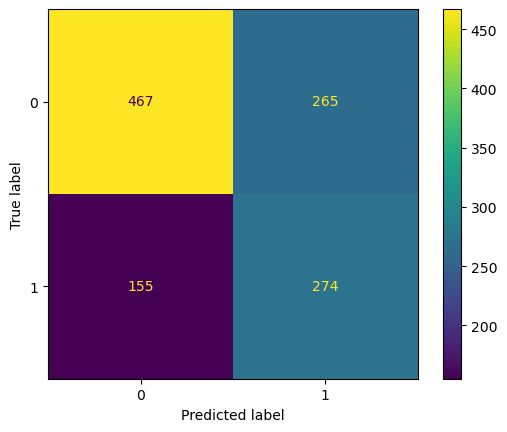

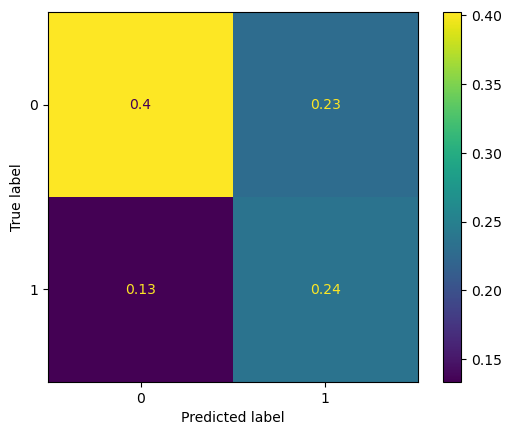

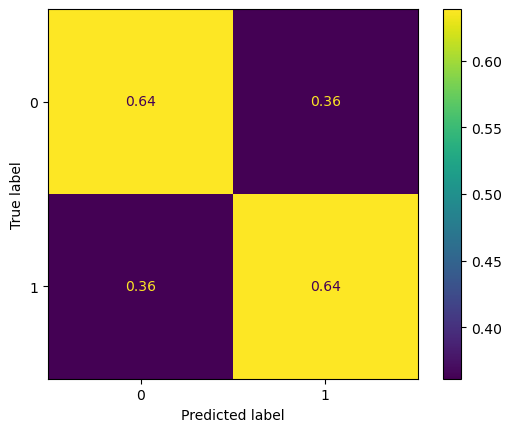



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.64      0.69       732
           1       0.51      0.64      0.57       429

    accuracy                           0.64      1161
   macro avg       0.63      0.64      0.63      1161
weighted avg       0.66      0.64      0.64      1161

ROC AUC: 0.7005553644897907


In [7]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

model = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model.fit(X, y)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))



=== Raza: caucasian ===


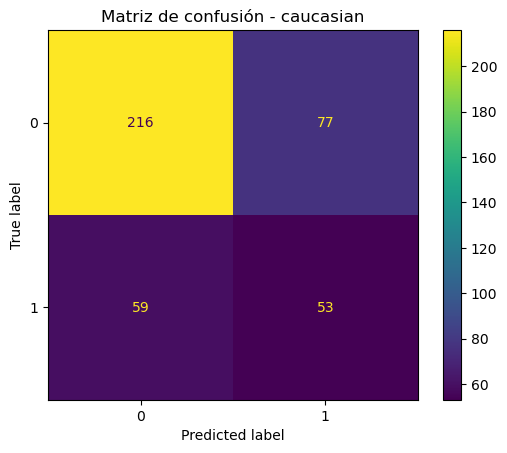

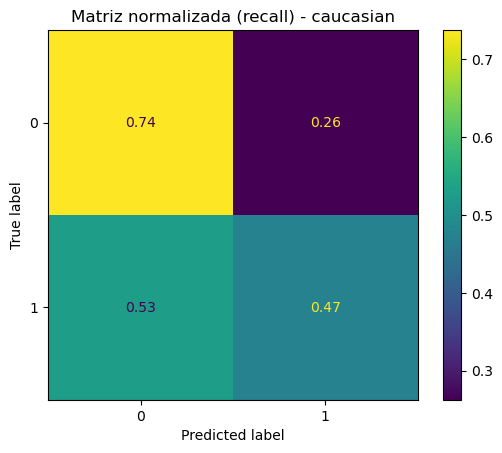


=== Raza: african-american ===


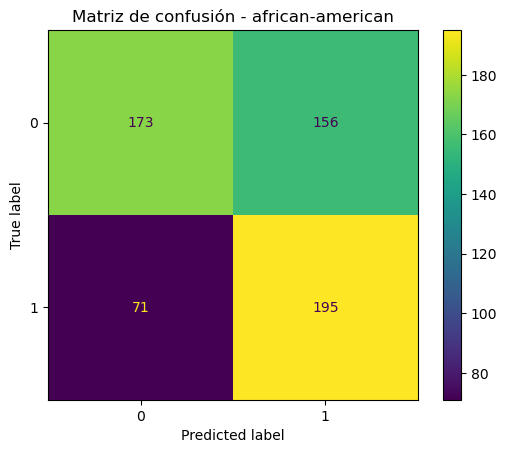

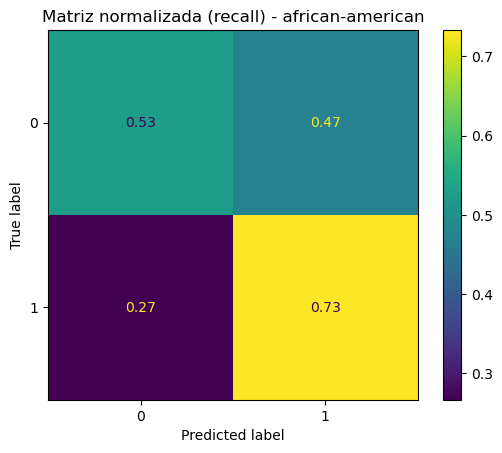


=== Raza: other ===


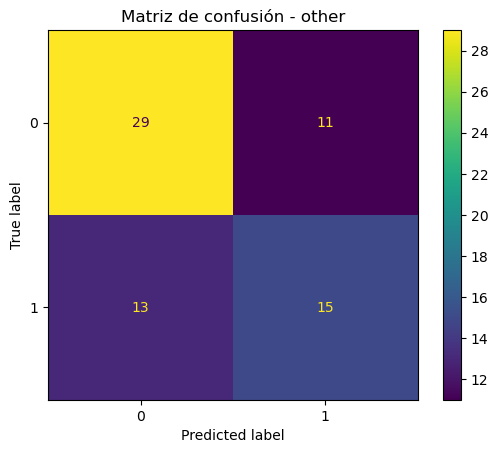

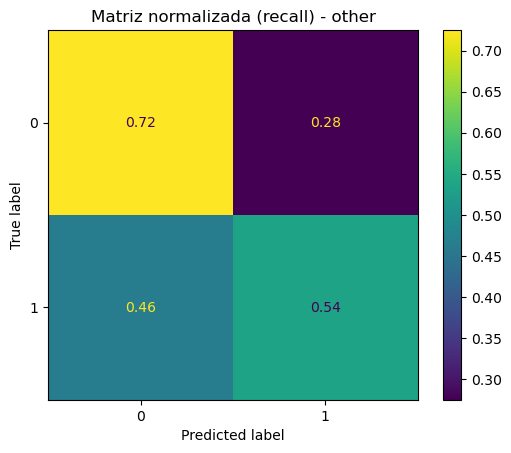


=== Raza: hispanic ===


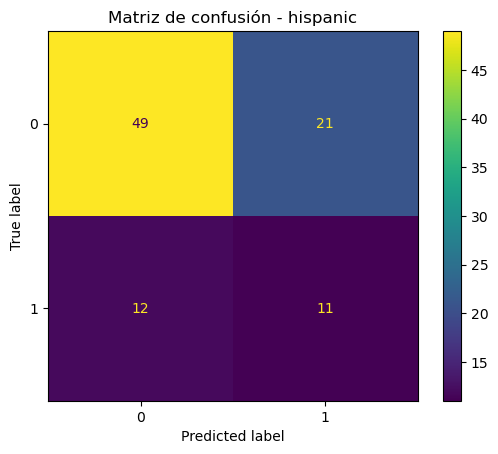

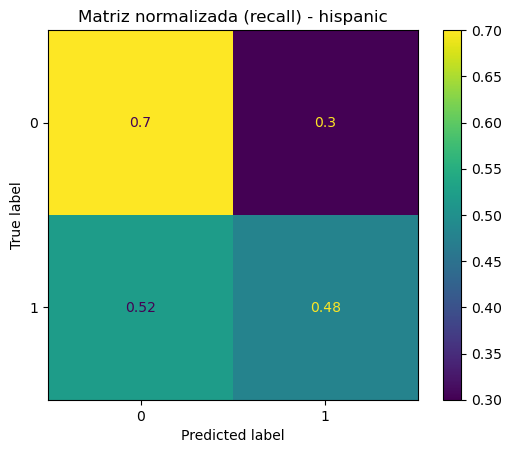

In [95]:
race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

In [8]:
# Probar con priors_count en función de la edad (ej: 4 antecedentes en 4 años vs 10 antecedentes en 40 años)

## Modelo v.1.1

In [18]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'days_in_jail', 'priors_count', 'juv_priors_count', 'c_charge_degree',
       'maritalstatus', 'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3'],
      dtype='object')

In [19]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq', 'priors_freq_2',
       'priors_freq_3']

In [77]:
X1 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y1 = df_sin_outliers['two_year_recid']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.2, random_state = 69, stratify = y1)

model1 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model1.fit(X1_train, y1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.37).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y1_test, y1_pred))
print("\nReporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

coeficientes = pd.DataFrame({
    'Variable': X1.columns,
    'Coeficiente': model1.coef_[0]
})

print(coeficientes)

Matriz de confusión:
[[527 205]
 [156 273]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       732
           1       0.57      0.64      0.60       429

    accuracy                           0.69      1161
   macro avg       0.67      0.68      0.67      1161
weighted avg       0.70      0.69      0.69      1161

ROC AUC: 0.7286961672207575
                          Variable  Coeficiente
0                              sex    -0.412478
1                              age    -0.016382
2                     days_in_jail     0.003135
3                 juv_priors_count     0.140742
4                  c_charge_degree    -0.101878
5              maritalstatus_other     0.048638
6          maritalstatus_separated    -0.120741
7  maritalstatus_significant other    -0.083826
8                    priors_freq_2     5.272905


Matriz de confusión:




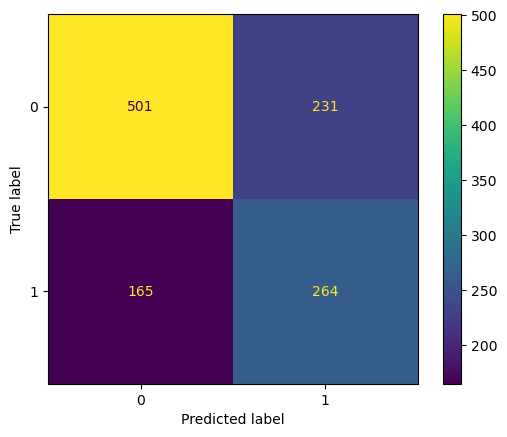

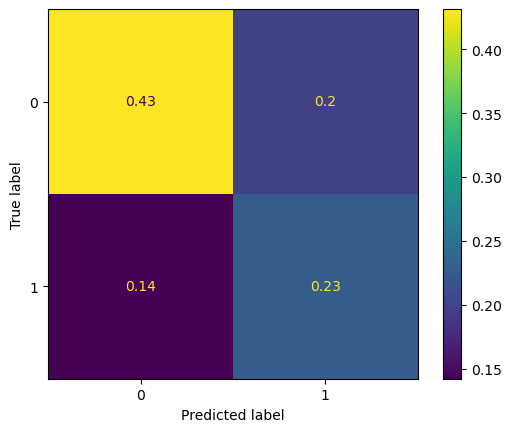

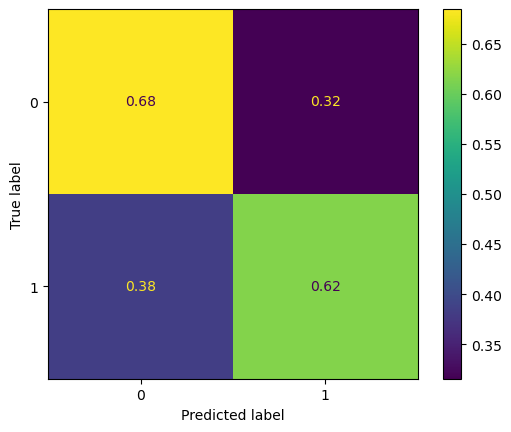



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.68      0.72       732
           1       0.53      0.62      0.57       429

    accuracy                           0.66      1161
   macro avg       0.64      0.65      0.64      1161
weighted avg       0.67      0.66      0.66      1161

ROC AUC: 0.7025997681735388


In [83]:
X1 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y1 = df_sin_outliers['two_year_recid']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.2, random_state = 42, stratify = y1)

model1 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model1.fit(X1_train, y1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))


=== Raza: caucasian ===


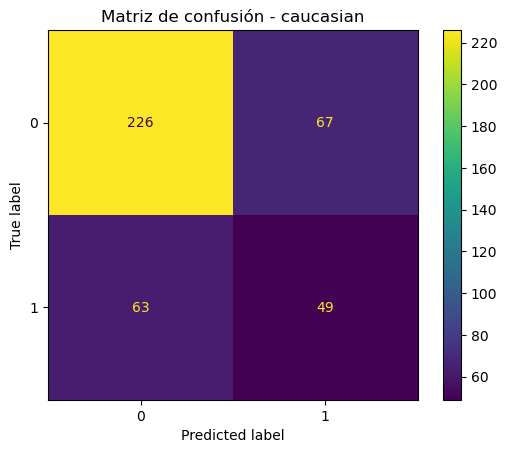

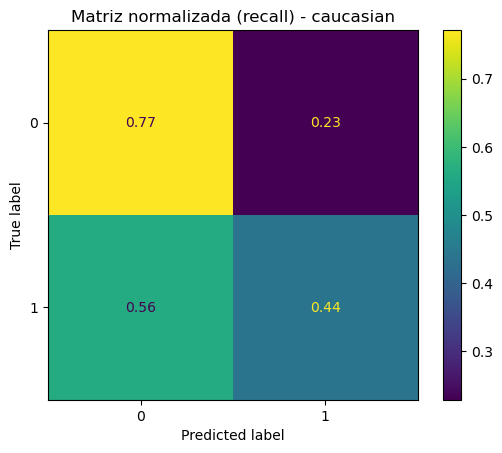


=== Raza: african-american ===


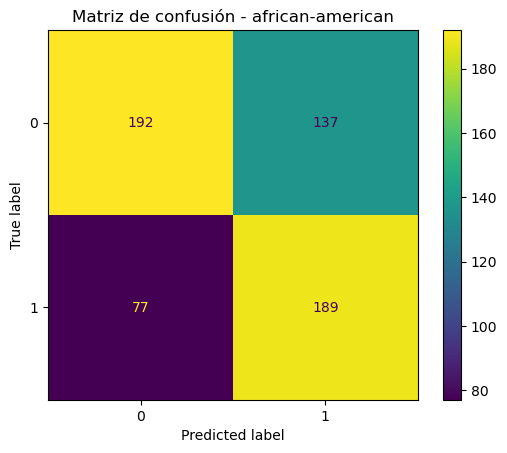

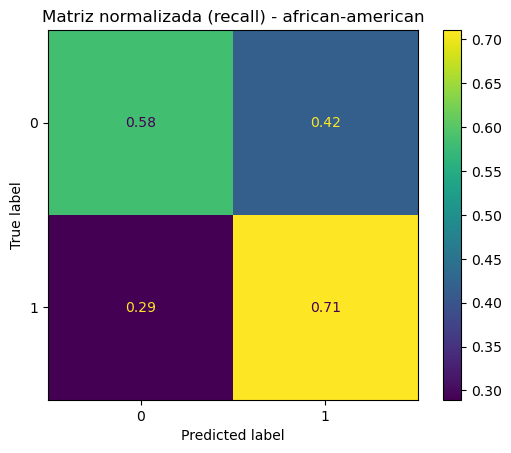


=== Raza: other ===


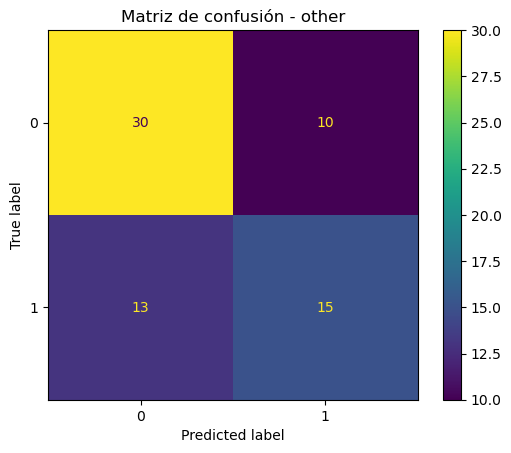

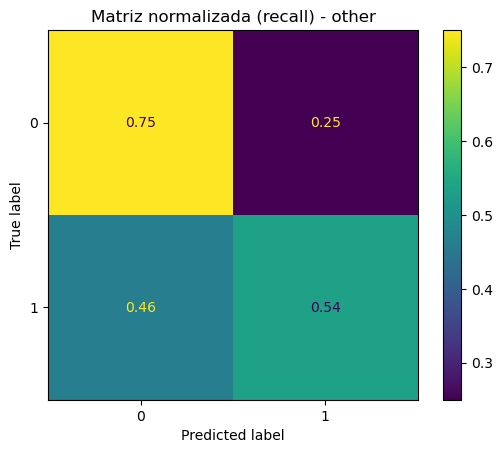


=== Raza: hispanic ===


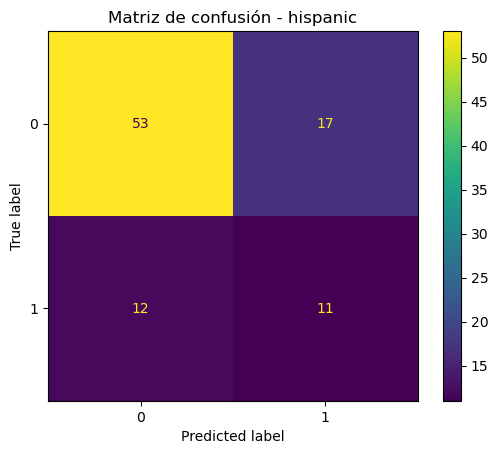

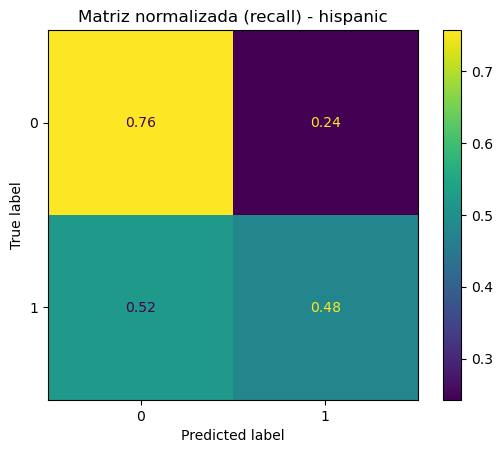

In [94]:
race_test = df_sin_outliers.loc[X1_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

## Modelo v.1.2

In [26]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'days_in_jail', 'priors_count', 'juv_priors_count', 'c_charge_degree',
       'maritalstatus', 'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3'],
      dtype='object')

In [41]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'priors_freq',
       'priors_freq_2']

In [79]:
X2 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y2 = df_sin_outliers['two_year_recid']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 69, stratify = y2)

model2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.37).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y2_test, y2_pred))
print("\nReporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

coeficientes = pd.DataFrame({
    'Variable': X2.columns,
    'Coeficiente': model2.coef_[0]
})

print(coeficientes)

Matriz de confusión:
[[527 205]
 [156 273]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       732
           1       0.57      0.64      0.60       429

    accuracy                           0.69      1161
   macro avg       0.67      0.68      0.67      1161
weighted avg       0.70      0.69      0.69      1161

ROC AUC: 0.7286897983619295
                          Variable  Coeficiente
0                              sex    -0.412489
1                              age    -0.016390
2                     days_in_jail     0.003135
3                 juv_priors_count     0.140717
4                  c_charge_degree    -0.101841
5              maritalstatus_other     0.048726
6          maritalstatus_separated    -0.120663
7  maritalstatus_significant other    -0.083779
8                    priors_freq_2     5.272847


Matriz de confusión:




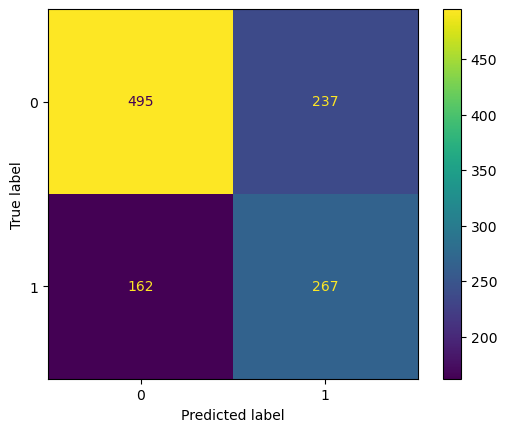

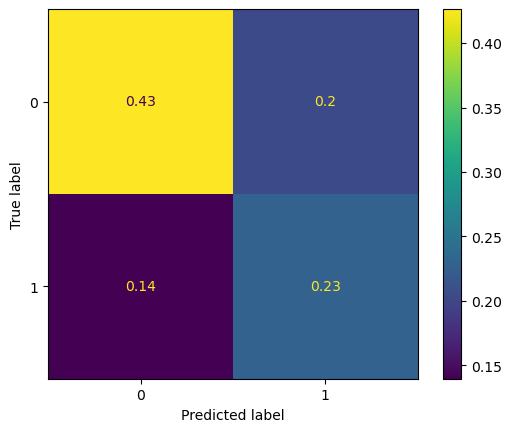

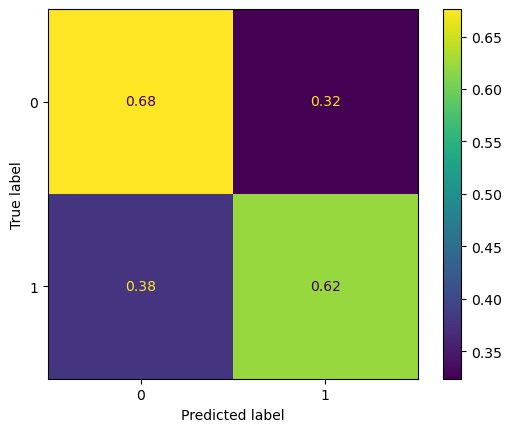



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71       732
           1       0.53      0.62      0.57       429

    accuracy                           0.66      1161
   macro avg       0.64      0.65      0.64      1161
weighted avg       0.67      0.66      0.66      1161

ROC AUC: 0.7008833607194263


In [84]:
X2 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y2 = df_sin_outliers['two_year_recid']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 42, stratify = y2)

model2 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))


=== Raza: caucasian ===


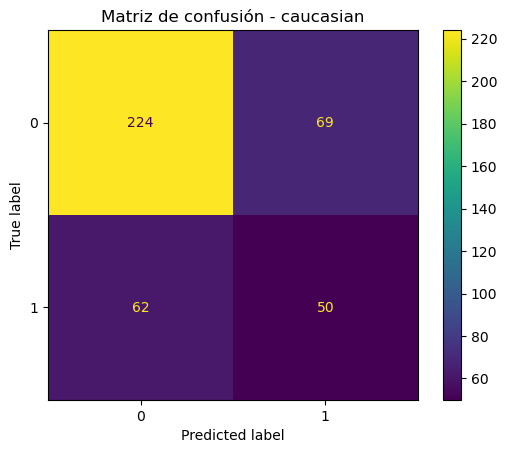

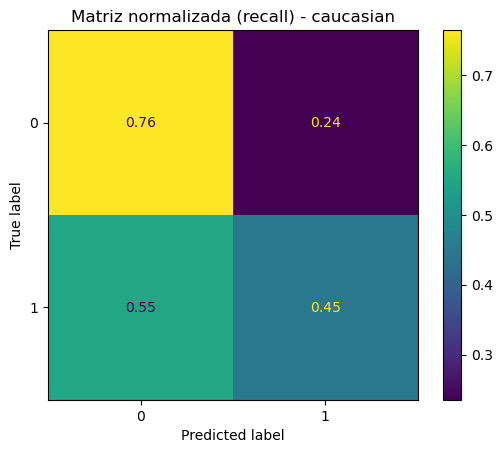


=== Raza: african-american ===


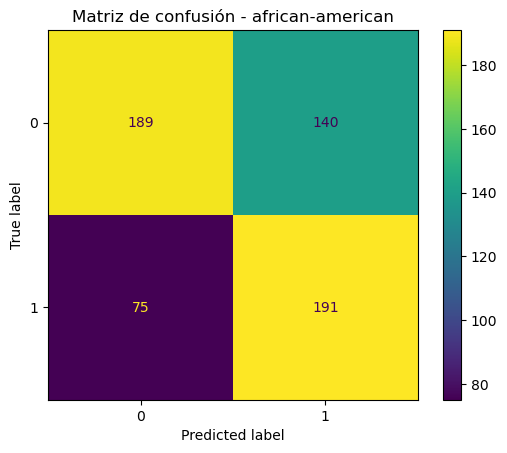

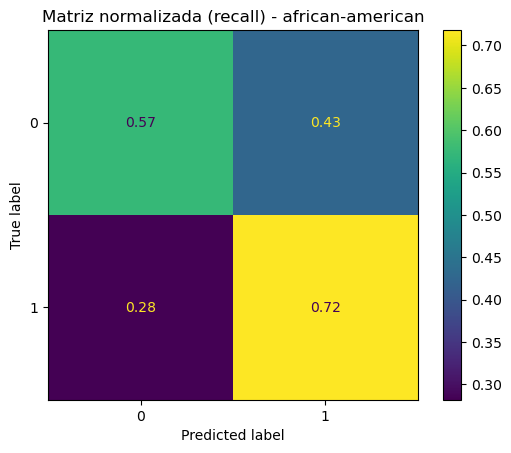


=== Raza: other ===


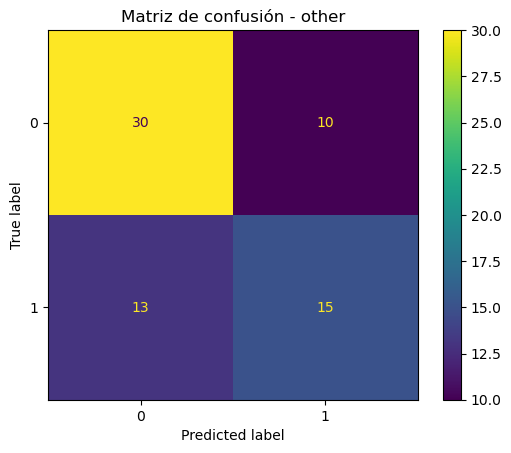

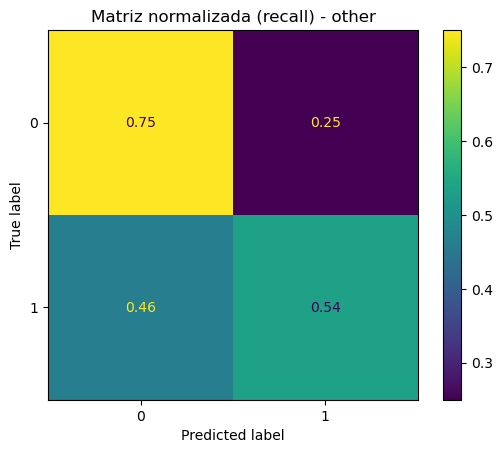


=== Raza: hispanic ===


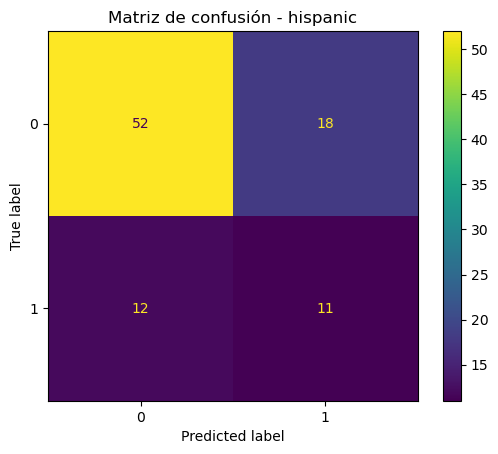

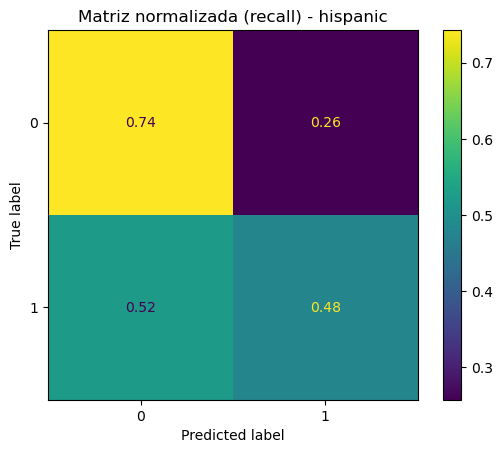

In [93]:
race_test = df_sin_outliers.loc[X2_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y2_test[idx]
    y_pred_r = y2_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

## Modelo v1.3

In [61]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age',
       'days_in_jail', 'priors_count', 'juv_priors_count', 'c_charge_degree',
       'maritalstatus', 'maritalstatus_other', 'maritalstatus_separated',
       'maritalstatus_significant other', 'priors_freq', 'priors_freq_2',
       'priors_freq_3'],
      dtype='object')

In [74]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race',
       'priors_freq_3', 'priors_freq', 'priors_count']

In [85]:
X3 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y3 = df_sin_outliers['two_year_recid']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size = 0.2, random_state = 69, stratify = y3)

model3 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.37).astype(int)

print("Matriz de confusión:")
print(confusion_matrix(y3_test, y3_pred))
print("\nReporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

coeficientes = pd.DataFrame({
    'Variable': X3.columns,
    'Coeficiente': model3.coef_[0]
})

print(coeficientes)

Matriz de confusión:
[[527 205]
 [156 273]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74       732
           1       0.57      0.64      0.60       429

    accuracy                           0.69      1161
   macro avg       0.67      0.68      0.67      1161
weighted avg       0.70      0.69      0.69      1161

ROC AUC: 0.7287025360795854
                          Variable  Coeficiente
0                              sex    -0.412414
1                              age    -0.016369
2                     days_in_jail     0.003135
3                 juv_priors_count     0.140762
4                  c_charge_degree    -0.101761
5              maritalstatus_other     0.048589
6          maritalstatus_separated    -0.120845
7  maritalstatus_significant other    -0.083842
8                    priors_freq_2     5.273800


Matriz de confusión:




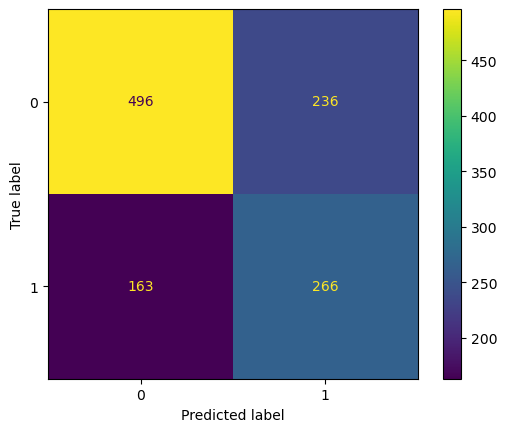

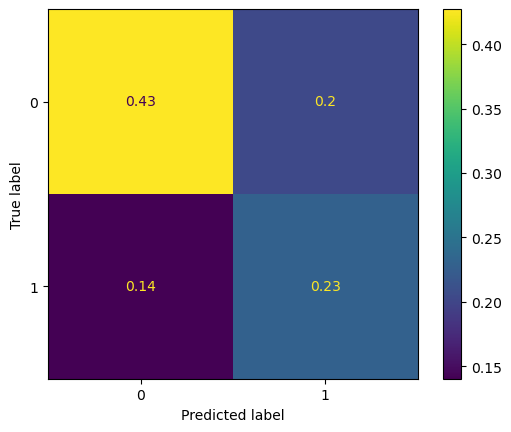

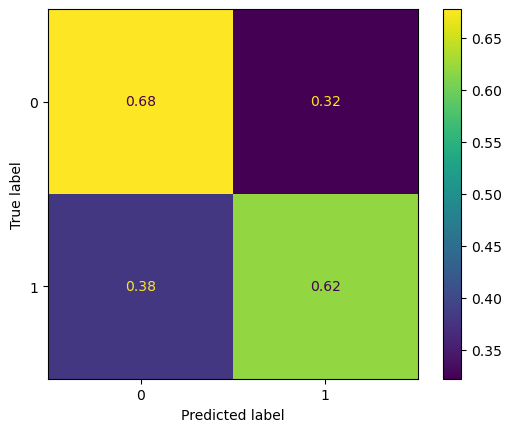



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.68      0.71       732
           1       0.53      0.62      0.57       429

    accuracy                           0.66      1161
   macro avg       0.64      0.65      0.64      1161
weighted avg       0.67      0.66      0.66      1161

ROC AUC: 0.7015839351904926


In [86]:
X3 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y3 = df_sin_outliers['two_year_recid']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size = 0.2, random_state = 42, stratify = y3)

model3 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))


=== Raza: caucasian ===


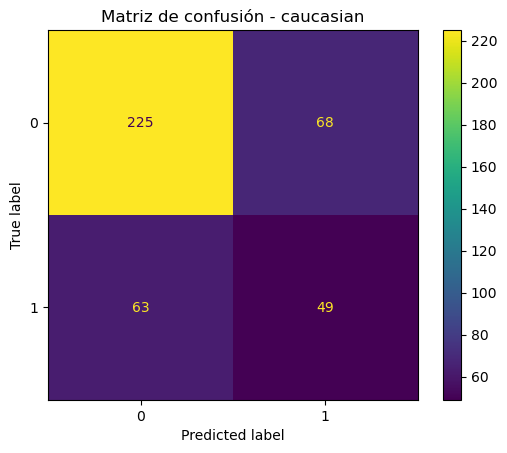

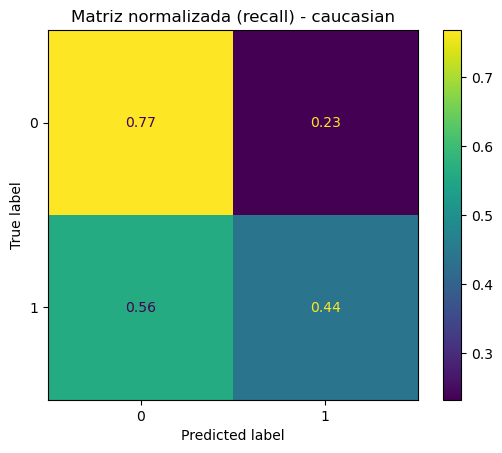


=== Raza: african-american ===


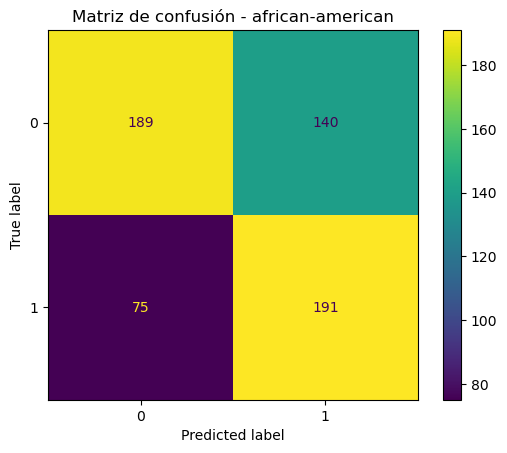

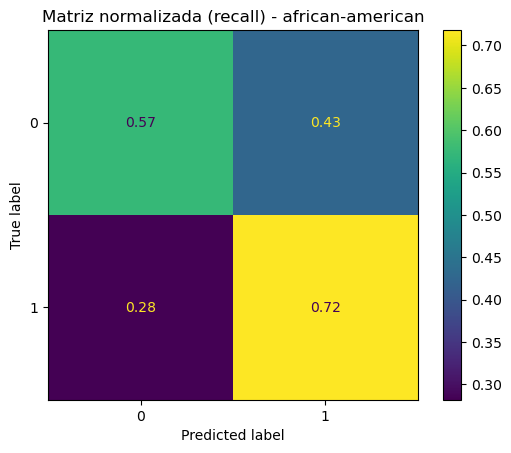


=== Raza: other ===


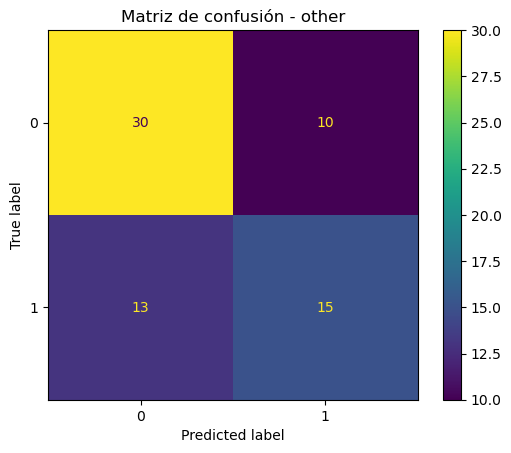

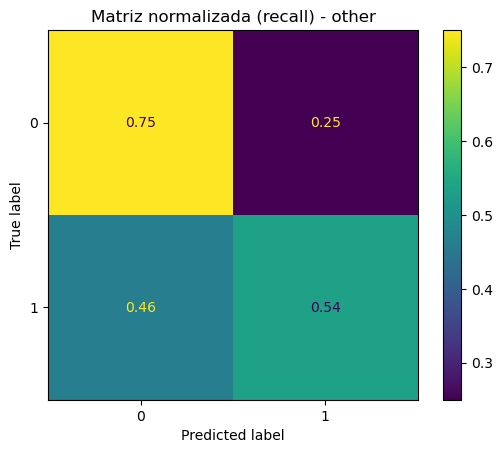


=== Raza: hispanic ===


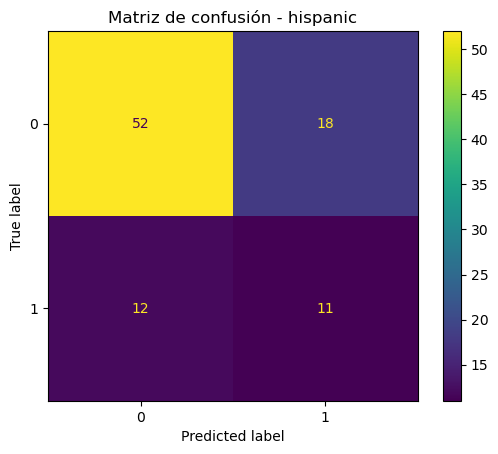

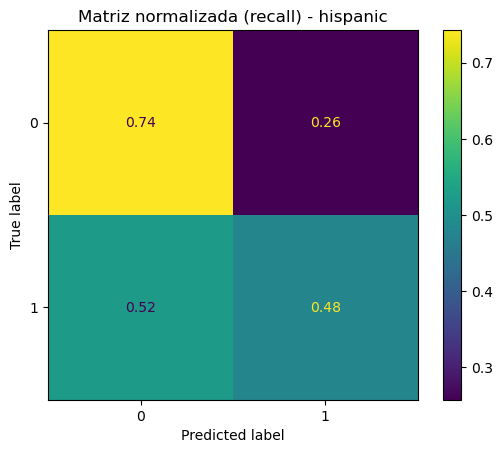

In [89]:
race_test = df_sin_outliers.loc[X3_test.index, 'race']

razas = race_test.unique()

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y3_test[idx]
    y_pred_r = y3_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()